# VoiceBank Speech Enhancement: Feature Dataset, DataLoader, and Model Definition
**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.

This notebook defines a PyTorch-compatible dataset class to load precomputed log-Mel spectrogram features (.npy files) for training a speech enhancement model.

**Notebook Overview**:
- Load the saved .npy features (noisy and clean log-Mel spectrograms).
- Define a FeatureDataset class.
- Create DataLoaders for training and validation.
- Implements a UNet model for speech enhancement
- Runs a sanity check forward pass
- Visualization to inspect batches.

**Next Steps**:
- Build and train the neural network model
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.nn as nn


data_root = "/kaggle/input/voicebank-demand"

## FeatureDataset class

In [2]:
class FeatureDataset(Dataset):
    """
    Loads precomputed Mel spectrogram features stored as .npy files.
    Each sample returns a (noisy, clean) pair.
    """
    def __init__(self, feature_dir, file_list):
        """
        Args:
            feature_dir (str): directory where features are stored
            file_list (list): list of filenames to load (without extension differences)
        """
        self.feature_dir = feature_dir
        # collect list of noisy and clean files pairs
        self.file_list = file_list  
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        base_name = self.file_list[idx]
        # Load noisy and clean features
        noisy_path = os.path.join(self.feature_dir, "noisy", base_name + ".npy")
        clean_path = os.path.join(self.feature_dir, "clean", base_name + ".npy")

        
        noisy_feat = np.load(noisy_path)
        clean_feat = np.load(clean_path)

        # Convert to torch tensors (float32)
        noisy_tensor = torch.tensor(noisy_feat, dtype=torch.float32)
        clean_tensor = torch.tensor(clean_feat, dtype=torch.float32)

        return noisy_tensor, clean_tensor

## Prepare file list of file pairs

In [3]:
def get_file_list(feature_dir):
    noisy_dir = os.path.join(feature_dir, "noisy")
    # only using noisy to get file names
    files = [f.replace(".npy", "") for f in os.listdir(noisy_dir) if f.endswith(".npy")]
    return sorted(files)

## Training and validation split of dataset

In [4]:
#running on kaggle
feature_dir = "/kaggle/input/voicebank-features/voicebank_features/logmel"
# running on pc
# feature_dir = "voicebank_features/logmel"
def create_datasets(feature_dir, val_ratio=0.1, seed=42):
    file_list = get_file_list(feature_dir)

    train_files, val_files = train_test_split(
        file_list, test_size=val_ratio, random_state=seed
    )

    train_dataset = FeatureDataset(feature_dir, train_files)
    val_dataset = FeatureDataset(feature_dir, val_files)

    return train_dataset, val_dataset

## Define DataLoaders

In [5]:
def create_dataloaders(feature_dir, batch_size=32, val_ratio=0.1, seed=42):
    train_dataset, val_dataset = create_datasets(feature_dir, val_ratio, seed)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [6]:
if __name__ == "__main__":
    #running on kaggle
    feature_dir = "/kaggle/input/voicebank-features/voicebank_features/logmel"
    # running on pc
    # feature_dir = "voicebank_features/logmel"
    batch_size = 16

    train_loader, val_loader = create_dataloaders(feature_dir, batch_size=batch_size)

    # check one batch
    for noisy, clean in train_loader:
        print("Noisy batch shape:", noisy.shape)
        print("Clean batch shape:", clean.shape)
        break

Noisy batch shape: torch.Size([16, 1, 64, 126])
Clean batch shape: torch.Size([16, 1, 64, 126])


Noisy shape: torch.Size([16, 1, 64, 126])
Clean shape: torch.Size([16, 1, 64, 126])


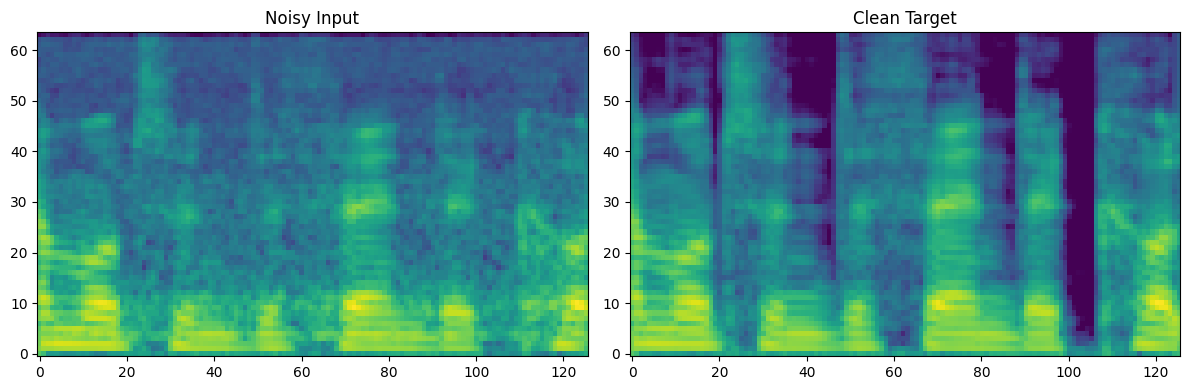

In [7]:
from IPython.display import Audio
# Visualize one batch from the training set
for noisy_batch, clean_batch in train_loader:
    print("Noisy shape:", noisy_batch.shape)   # (B, M, T)
    print("Clean shape:", clean_batch.shape)   # (B, M, T)
    noisy_batch = np.squeeze(noisy_batch)
    clean_batch = np.squeeze(clean_batch)
    idx = 0  # visualize first item
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(noisy_batch[idx], aspect='auto', origin='lower')
    plt.title("Noisy Input")
    
    plt.subplot(1, 2, 2)
    plt.imshow(clean_batch[idx], aspect='auto', origin='lower')
    plt.title("Clean Target")
    plt.tight_layout()
    plt.show()
     
    break



## Model Definition: Baseline CNN

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 16 * 16, 128)  # adjust depending on input size
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)   # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
#unet block
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [10]:
#unet
class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(UNet, self).__init__()

        # Encoder
        self.enc1 = UNetBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = UNetBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = UNetBlock(128, 256)

        # Decoder
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(128, 64)

        # Final
        self.conv_final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        # Bottleneck
        b = self.bottleneck(self.pool2(e2))

        # Decoder
        d2 = self.up2(b)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.conv_final(d1)

## Test run

In [11]:
if __name__ == "__main__":
    # dummy input: batch=4, 1 channel, 64x64 features
    x = torch.randn(4, 1, 64, 64)
    model = SimpleCNN(input_channels=1, num_classes=10)
    #model = UNet(in_channels=1, num_classes=10)
    out = model(x)

    print("Input shape:", x.shape)
    print("Output shape:", out.shape)  # expect [4, num_classes, 64, 64]


Input shape: torch.Size([4, 1, 64, 64])
Output shape: torch.Size([4, 10])
